Confusion Matrix:
 [[377  42]
 [ 81 100]]
Accuracy     : 0.7950
Precision    : 0.7042
Recall       : 0.5525
F1-Score     : 0.6192
ROC-AUC      : 0.8698

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86       419
           1       0.70      0.55      0.62       181

    accuracy                           0.80       600
   macro avg       0.76      0.73      0.74       600
weighted avg       0.79      0.80      0.79       600



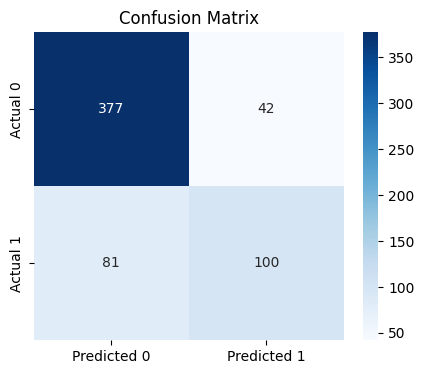

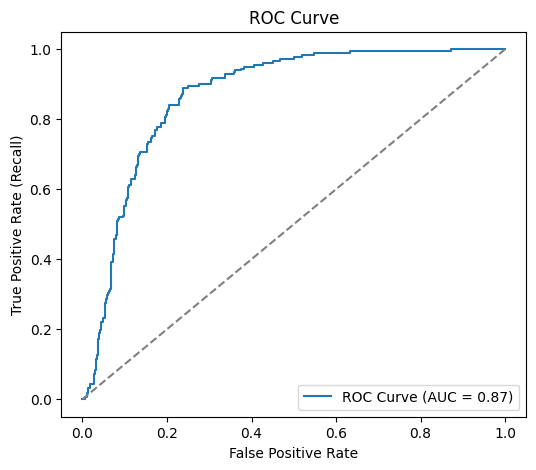

In [1]:
# ===============================
# Machine Learning Metrics Demo
# ===============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, classification_report
)

# 1. Generate synthetic binary classification dataset
X, y = make_classification(
    n_samples=2000, n_features=10, n_informative=5, n_redundant=2,
    random_state=42, weights=[0.7, 0.3]  # imbalanced classes
)

# 2. Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 4. Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probabilities for ROC

# 5. Metrics Calculation
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Print metrics
print("Confusion Matrix:\n", cm)
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}")
print(f"Recall       : {rec:.4f}")
print(f"F1-Score     : {f1:.4f}")
print(f"ROC-AUC      : {roc_auc:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 6. Confusion Matrix Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion Matrix")
plt.show()

# 7. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [15]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df=pd.read_csv("C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTrain+.txt")
df.head()

,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,...,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [19]:
columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','class','level'])
df.columns = columns

In [20]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,level
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [21]:

df.tail()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,level
125967,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.0,1.00,1.0,0.00,0.0,neptune,20
125968,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.0,0.00,0.0,0.00,0.0,normal,21
125969,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.0,0.72,0.0,0.01,0.0,normal,18
125970,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.0,1.00,1.0,0.00,0.0,neptune,20
125971,0,tcp,ftp_data,SF,151,0,0,0,0,0,...,0.30,0.03,0.30,0.0,0.00,0.0,0.00,0.0,normal,21


In [22]:
df['binary_attack'] = df['class'].apply(lambda x: 0 if x == 'normal' else 1)

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_10120\3911870635.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='binary_attack', data=df, palette = 'pastel')


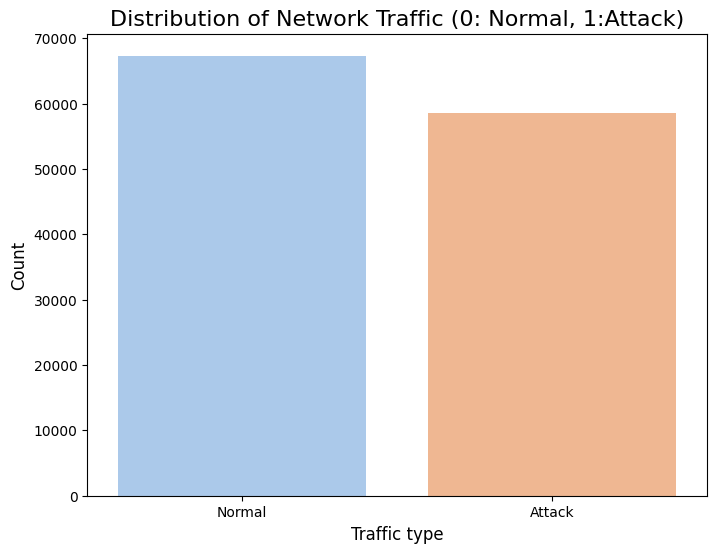

binary_attack
0    0.534579
1    0.465421
Name: proportion, dtype: float64


In [23]:
plt.figure(figsize=(8,6))
sns.countplot(x='binary_attack', data=df, palette = 'pastel')
plt.title('Distribution of Network Traffic (0: Normal, 1:Attack)', fontsize=16)
plt.xlabel('Traffic type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0,1], ['Normal', 'Attack'])
plt.show()

print(df['binary_attack'].value_counts(normalize=True))

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# =========================
# 1. Load Dataset
# =========================
train_path = "c://Users//pm5cd//Documents//SentinelNet-AI//SentinelNet//data//NSL-KDD//KDDTrain+.txt"

cols = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment',
    'urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted',
    'num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label','extra'
]

df = pd.read_csv("C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTrain+.txt", names=cols)

# =========================
# 2. Preprocess
# =========================
# Normalize labels
df['label'] = df['label'].astype(str).str.strip().str.lower()
df['label'] = df['label'].apply(lambda x: 0 if x == "normal" else 1)

print("Class distribution:\n", df['label'].value_counts())

# Features
cat_cols = ['protocol_type', 'service', 'flag']
num_cols = [c for c in df.columns if c not in cat_cols + ['label','extra']]

# One-hot encode categorical
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat = encoder.fit_transform(df[cat_cols])

# Scale numeric
scaler = StandardScaler()
X_num = scaler.fit_transform(df[num_cols])

# Combine
X = np.hstack([X_num, X_cat])
y = df['label'].values

# =========================
# 3. Train/Test Split
# =========================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =========================
# 4. Train Model
# =========================
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# =========================
# 5. Evaluate
# =========================
y_pred = model.predict(X_val)

print("\n Accuracy:", accuracy_score(y_val, y_pred))
print("\n Classification Report:\n", classification_report(y_val, y_pred))


Class distribution:
 label
0    67343
1    58630
Name: count, dtype: int64

 Accuracy: 0.9988357324301439

 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     20203
           1       1.00      1.00      1.00     17589

    accuracy                           1.00     37792
   macro avg       1.00      1.00      1.00     37792
weighted avg       1.00      1.00      1.00     37792



Train label distribution:
 label
21    62557
18    20667
20    19339
19    10284
15     3990
17     3074
16     2393
12      729
14      674
11      641
13      451
10      253
9       194
7       118
8       106
6        96
5        81
4        79
0        66
3        65
1        62
2        54
Name: count, dtype: int64
Test label distribution:
 label
21    10694
18     2967
20     1343
15     1176
17     1168
19      890
14      736
16      681
13      519
12      486
11      461
7       249
10      195
6       157
8       131
0       123
3       116
9       106
5       103
4       101
1        87
2        55
Name: count, dtype: int64


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Confusion Matrix:
 [[    0     1     0     2     2     0     0     0     0     0     0     0
      0     0     0     0     0     2    18     0    20    78]
 [    0     1     3     3     0     0     0     0     0     0     0     0
      0     0     0     0     1     2    22     0    18    37]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     3     1     0     5     0    12    34]
 [    1     1     0     0     0     0     0     0     0     0     0     0
      0     0     0    33     2     3    19     2    29    26]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     3     1    28     1    35    33]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     1     6     3    26     0    41    26]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0    13     1    10    18     2    40    73]
 [    0     0     0  

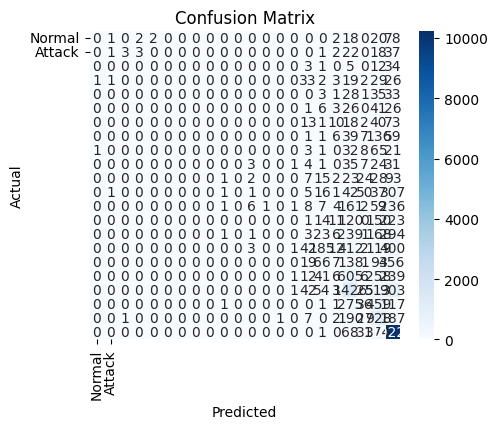

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_10120\2710149927.py:129: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


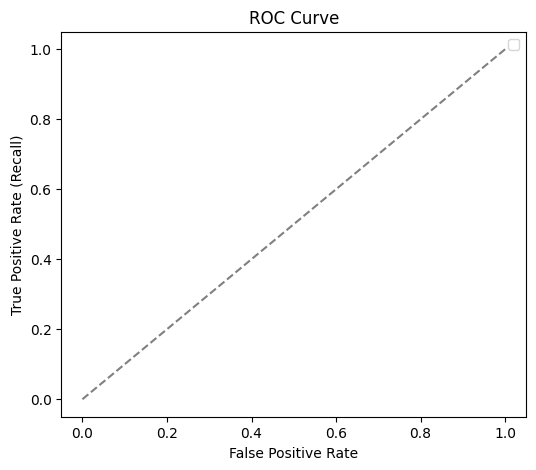

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, classification_report
)
from scipy.sparse import hstack

# ===============================
# 1. Load Dataset
# ===============================
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent",
    "hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label"
]

train_path = "C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTrain+.txt"
test_path = "C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTest+.txt"

train_df = pd.read_csv(train_path, names=col_names)
test_df = pd.read_csv(test_path, names=col_names)
print("Train label distribution:\n", train_df['label'].value_counts())
print("Test label distribution:\n", test_df['label'].value_counts())

# ===============================
# 2. Preprocessing
# ===============================
# Binary labels
# Convert labels to binary only if dtype is object (string), otherwise skip
if train_df['label'].dtype == object:
    train_df['label'] = train_df['label'].str.strip().apply(lambda x: 0 if x.lower() == "normal" else 1)
if test_df['label'].dtype == object:
    test_df['label'] = test_df['label'].str.strip().apply(lambda x: 0 if x.lower() == "normal" else 1)

# Columns
cat_cols = ['protocol_type','service','flag']
num_cols = [c for c in train_df.columns if c not in cat_cols+['label']]

# Convert numeric
train_df[num_cols] = train_df[num_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
test_df[num_cols] = test_df[num_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# ===============================
# 3. Feature Engineering (Memory Efficient)
# ===============================
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_train_cat = encoder.fit_transform(train_df[cat_cols])
X_test_cat = encoder.transform(test_df[cat_cols])

from scipy.sparse import csr_matrix

scaler = StandardScaler(with_mean=False)  # with_mean=False for sparse input
X_train_num = scaler.fit_transform(train_df[num_cols])
X_test_num = scaler.transform(test_df[num_cols])

# Convert numeric features to sparse matrices
X_train_num_sparse = csr_matrix(X_train_num)
X_test_num_sparse = csr_matrix(X_test_num)

# Combine sparse categorical + sparse numeric using hstack
X_train = hstack([X_train_num_sparse, X_train_cat])
X_test = hstack([X_test_num_sparse, X_test_cat])

y_train = train_df['label'].values
y_test = test_df['label'].values

# ===============================
# 4. Train Model
# ===============================
model = LogisticRegression(max_iter=1000, solver='saga', n_jobs=-1)  # 'saga' supports sparse input
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# ===============================
# 5. Metrics
# ===============================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
# For multiclass, roc_auc_score requires y_test to be one-hot and y_prob to be 2D; skip or handle separately if needed
try:
    roc_auc = roc_auc_score(y_test, y_prob)
except ValueError:
    roc_auc = None
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# ===============================
# 6. Confusion Matrix Plot
# ===============================
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Attack"],
            yticklabels=["Normal","Attack"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============================
# 7. ROC Curve
# ===============================
plt.figure(figsize=(6,5))
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()
